In [98]:
# BNK 로컬 챌린지 추천 시스템 MVP
## Enterprise-Level MLOps Pipeline Simulation

# **프로젝트 개요:**
# - 부산 지역 기반 O2O 플랫폼 추천 시스템
# - Cold Start 해결을 위한 Synthetic Data 생성
# - LightGBM 기반 추천 모델
# - 유저 피드백 기반 MLOps Loop 시뮬레이션


## Step 0: 환경 설정 및 라이브러리 Import

In [99]:
# 필수 라이브러리 Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# 머신러닝 라이브러리
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# 설정
np.random.seed(42)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("✅ 라이브러리 Import 완료")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"LightGBM version: {lgb.__version__}")

✅ 라이브러리 Import 완료
Pandas version: 2.3.2
NumPy version: 2.3.3
LightGBM version: 4.6.0


In [100]:
# Haversine 공식 구현 (GPS 거리 계산)
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    두 GPS 좌표 간의 거리를 미터 단위로 계산
    
    Parameters:
    - lat1, lon1: 첫 번째 좌표 (위도, 경도)
    - lat2, lon2: 두 번째 좌표 (위도, 경도)
    
    Returns:
    - 거리 (미터)
    """
    R = 6371000  # 지구 반지름 (미터)
    
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    
    return R * c

print("✅ Haversine 거리 계산 함수 정의 완료")

✅ Haversine 거리 계산 함수 정의 완료


## Step 1: TB_MISSION 데이터 생성 (Fixed 20 Missions)

In [101]:
# TB_MISSION: 부산 지역 20개 고정 미션 데이터 (실제 좌표 기반)
mission_data = [
    # Food (맛집) - req_time_min: 40분, reward_amt: 50
    {"mission_id": "M001", "category": "Food", "title": "자갈치시장 꼼장어 골목 방문", 
     "lat": 35.0968, "lon": 129.0306, "req_time_min": 40, "reward_amt": 50},
    {"mission_id": "M002", "category": "Food", "title": "부산대 앞 토스트 골목 간식타임", 
     "lat": 35.2327, "lon": 129.0823, "req_time_min": 40, "reward_amt": 50},
    
    # Cafe (카페) - req_time_min: 30분, reward_amt: 50
    {"mission_id": "M003", "category": "Cafe", "title": "전포 카페거리 힙한 카페 찾기", 
     "lat": 35.1557, "lon": 129.0629, "req_time_min": 30, "reward_amt": 50},
    {"mission_id": "M004", "category": "Cafe", "title": "영도 흰여울문화마을 오션뷰 카페", 
     "lat": 35.0768, "lon": 129.0419, "req_time_min": 30, "reward_amt": 50},
    
    # Tourist (관광) - req_time_min: 10분, reward_amt: 100
    {"mission_id": "M005", "category": "Tourist", "title": "해운대 블루라인파크 해변열차 구경", 
     "lat": 35.1876, "lon": 129.2068, "req_time_min": 10, "reward_amt": 100},
    {"mission_id": "M006", "category": "Tourist", "title": "감천문화마을 어린왕자와 사진찍기", 
     "lat": 35.0976, "lon": 129.0104, "req_time_min": 10, "reward_amt": 100},
    
    # Culture (문화생활) - req_time_min: 60분, reward_amt: 250
    {"mission_id": "M007", "category": "Culture", "title": "영화의전당 시네마테크 관람", 
     "lat": 35.1716, "lon": 129.1307, "req_time_min": 60, "reward_amt": 250},
    {"mission_id": "M008", "category": "Culture", "title": "부산시립미술관 전시회 관람", 
     "lat": 35.1729, "lon": 129.1296, "req_time_min": 60, "reward_amt": 250},
    {"mission_id": "M009", "category": "Culture", "title": "F1963 복합문화공간 방문", 
     "lat": 35.1506, "lon": 129.0629, "req_time_min": 60, "reward_amt": 250},
    
    # Festival (축제) - req_time_min: 10분, reward_amt: 100
    {"mission_id": "M010", "category": "Festival", "title": "광안리 해수욕장 불꽃축제 명당 찾기", 
     "lat": 35.1532, "lon": 129.1189, "req_time_min": 10, "reward_amt": 100},
    {"mission_id": "M011", "category": "Festival", "title": "BIFF 광장 먹자골목 투어", 
     "lat": 35.0989, "lon": 129.0305, "req_time_min": 10, "reward_amt": 100},
    
    # Walk (산책) - req_time_min: 20분, reward_amt: 200
    {"mission_id": "M012", "category": "Walk", "title": "부산시민공원 20분 걷기 챌린지", 
     "lat": 35.1687, "lon": 129.0571, "req_time_min": 20, "reward_amt": 200},
    {"mission_id": "M013", "category": "Walk", "title": "동백섬 산책로 한 바퀴 돌기", 
     "lat": 35.1588, "lon": 129.1345, "req_time_min": 20, "reward_amt": 200},
    {"mission_id": "M014", "category": "Walk", "title": "온천천 벚꽃길 산책 코스 완주", 
     "lat": 35.1971, "lon": 129.0857, "req_time_min": 20, "reward_amt": 200},
    
    # Shopping (쇼핑/장보기) - req_time_min: 30분, reward_amt: 150
    {"mission_id": "M015", "category": "Shopping", "title": "부전시장 장보기 챌린지", 
     "lat": 35.1639, "lon": 129.0604, "req_time_min": 30, "reward_amt": 150},
    {"mission_id": "M016", "category": "Shopping", "title": "신세계 센텀시티 아이쇼핑", 
     "lat": 35.1688, "lon": 129.1306, "req_time_min": 30, "reward_amt": 150},
    {"mission_id": "M017", "category": "Shopping", "title": "국제시장 구제골목 탐방", 
     "lat": 35.0998, "lon": 129.0304, "req_time_min": 30, "reward_amt": 150},
    
    # Self-Dev (자기계발) - req_time_min: 60분, reward_amt: 300
    {"mission_id": "M018", "category": "Self-Dev", "title": "부산은행 본점(BIFC) 금융센터 방문", 
     "lat": 35.1143, "lon": 129.0476, "req_time_min": 60, "reward_amt": 300},
    {"mission_id": "M019", "category": "Self-Dev", "title": "부산광역시립도서관 열람실 이용", 
     "lat": 35.2052, "lon": 129.0863, "req_time_min": 60, "reward_amt": 300},
    {"mission_id": "M020", "category": "Self-Dev", "title": "영풍문고 광복점 베스트셀러 구경", 
     "lat": 35.0989, "lon": 129.0311, "req_time_min": 60, "reward_amt": 300},
    
    # Sports (스포츠) - req_time_min: 40분, reward_amt: 200
    {"mission_id": "M021", "category": "Sports", "title": "사직야구장 롯데 자이언츠 직관", 
     "lat": 35.1940, "lon": 129.0615, "req_time_min": 40, "reward_amt": 200},
    {"mission_id": "M022", "category": "Sports", "title": "BNK 썸 농구단 홈경기 응원", 
     "lat": 35.1937, "lon": 129.0608, "req_time_min": 40, "reward_amt": 200},
    {"mission_id": "M023", "category": "Sports", "title": "삼락생태공원 자전거 라이딩", 
     "lat": 35.1808, "lon": 128.9856, "req_time_min": 40, "reward_amt": 200},
]

df_mission = pd.DataFrame(mission_data)

print(f"✅ TB_MISSION 생성 완료: {len(df_mission)}개 미션")
print(f"\n카테고리별 분포:")
print(df_mission['category'].value_counts())
print(f"\n미션 데이터 샘플:")
df_mission.head(10)

✅ TB_MISSION 생성 완료: 23개 미션

카테고리별 분포:
category
Culture     3
Walk        3
Shopping    3
Self-Dev    3
Sports      3
Food        2
Cafe        2
Tourist     2
Festival    2
Name: count, dtype: int64

미션 데이터 샘플:


,mission_id,category,title,lat,lon,req_time_min,reward_amt
0,M001,Food,자갈치시장 꼼장어 골목 방문,35.0968,129.0306,40,50
1,M002,Food,부산대 앞 토스트 골목 간식타임,35.2327,129.0823,40,50
2,M003,Cafe,전포 카페거리 힙한 카페 찾기,35.1557,129.0629,30,50
3,M004,Cafe,영도 흰여울문화마을 오션뷰 카페,35.0768,129.0419,30,50
4,M005,Tourist,해운대 블루라인파크 해변열차 구경,35.1876,129.2068,10,100
5,M006,Tourist,감천문화마을 어린왕자와 사진찍기,35.0976,129.0104,10,100
6,M007,Culture,영화의전당 시네마테크 관람,35.1716,129.1307,60,250
7,M008,Culture,부산시립미술관 전시회 관람,35.1729,129.1296,60,250
8,M009,Culture,F1963 복합문화공간 방문,35.1506,129.0629,60,250
9,M010,Festival,광안리 해수욕장 불꽃축제 명당 찾기,35.1532,129.1189,10,100


## Step 2: 미션 우선도 설정 (운영자 설정 방식)

In [102]:
# 운영자가 미션 등록 시 직접 설정하는 우선도 (0~3)
# Priority Weight 정책:
# - 0: 일반 미션 (가중치 1.0)
# - 1: 약간 중요 (가중치 1.1) - 예: 제휴 이벤트
# - 2: 중요 (가중치 1.2) - 예: 프로모션 미션
# - 3: 매우 중요 (가중치 1.3) - 예: 전략적 제휴사 미션

# 각 미션에 대한 운영자의 비즈니스 판단 기반 우선도 설정
priority_weights = {
    "M001": 1,  # 자갈치시장 - 지역 상권 활성화
    "M002": 0,  # 부산대 토스트 - 일반
    "M003": 0,  # 전포 카페 - 일반
    "M004": 1,  # 흰여울 카페 - 관광지 연계
    "M005": 2,  # 해운대 블루라인 - 부산 대표 관광
    "M006": 2,  # 감천문화마을 - 부산 대표 관광
    "M007": 1,  # 영화의전당 - 문화 시설
    "M008": 1,  # 시립미술관 - 문화 시설
    "M009": 1,  # F1963 - 문화 시설
    "M010": 3,  # 광안리 불꽃축제 - 부산 대표 축제
    "M011": 2,  # BIFF 광장 - 부산 영화제 연계
    "M012": 1,  # 시민공원 - 공공 시설
    "M013": 1,  # 동백섬 - 관광지
    "M014": 1,  # 온천천 - 지역 명소
    "M015": 1,  # 부전시장 - 지역 상권
    "M016": 2,  # 신세계 센텀 - 주요 제휴사
    "M017": 1,  # 국제시장 - 지역 상권
    "M018": 3,  # 부산은행 본점 - 핵심 제휴사 (BNK)
    "M019": 0,  # 시립도서관 - 일반
    "M020": 0,  # 영풍문고 - 일반
    "M021": 2,  # 사직야구장 롯데 자이언츠 - 주요 제휴 (롯데)
    "M022": 3,  # BNK 썸 농구단 - 핵심 제휴사 (BNK)
    "M023": 1,  # 삼락생태공원 - 공공 시설
}

# DataFrame에 priority_weight 추가
df_mission['priority_weight'] = df_mission['mission_id'].map(priority_weights)

print("✅ 미션 우선도 설정 완료 (운영자 설정 방식)")
print(f"\n우선도별 분포:")
print(df_mission['priority_weight'].value_counts().sort_index())
print(f"\n우선도가 높은 미션 (weight >= 2):")
print(df_mission[df_mission['priority_weight'] >= 2][['mission_id', 'title', 'priority_weight']].sort_values('priority_weight', ascending=False))
print(f"\n최종 가중치 계산 공식: weight = 1.0 + priority_weight × 0.1")
df_mission['final_weight'] = 1.0 + df_mission['priority_weight'] * 0.1
print(df_mission[['mission_id', 'title', 'priority_weight', 'final_weight']].head(10))

✅ 미션 우선도 설정 완료 (운영자 설정 방식)

우선도별 분포:
priority_weight
0     4
1    11
2     5
3     3
Name: count, dtype: int64

우선도가 높은 미션 (weight >= 2):
   mission_id                  title  priority_weight
9        M010    광안리 해수욕장 불꽃축제 명당 찾기                3
17       M018  부산은행 본점(BIFC) 금융센터 방문                3
21       M022       BNK 썸 농구단 홈경기 응원                3
4        M005     해운대 블루라인파크 해변열차 구경                2
5        M006      감천문화마을 어린왕자와 사진찍기                2
10       M011        BIFF 광장 먹자골목 투어                2
15       M016          신세계 센텀시티 아이쇼핑                2
20       M021       사직야구장 롯데 자이언츠 직관                2

최종 가중치 계산 공식: weight = 1.0 + priority_weight × 0.1
  mission_id                title  priority_weight  final_weight
0       M001      자갈치시장 꼼장어 골목 방문                1           1.1
1       M002    부산대 앞 토스트 골목 간식타임                0           1.0
2       M003     전포 카페거리 힙한 카페 찾기                0           1.0
3       M004    영도 흰여울문화마을 오션뷰 카페                1           1.1

## Step 3: TB_USER 생성 (1,000명의 부산 시민 - 미션 중심 좌표 분포)

In [103]:
# TB_USER 생성: 1,000명의 부산 시민
# 실제 부산 인구 분포 기반 (2024년 기준 행정구역별 인구 비율)

num_users = 1000
categories_list = df_mission['category'].unique().tolist()

# 부산광역시 행정구역별 인구 분포 및 GPS 범위
# 출처: 2024년 부산광역시 주민등록인구 통계 (대략적 비율)
BUSAN_DISTRICTS = {
    'Haeundae': {
        'lat_range': (35.14, 35.20), 
        'lon_range': (129.11, 129.23), 
        'code': '26350',
        'population_ratio': 0.12  # 약 40만명 (12%)
    },
    'Busanjin': {
        'lat_range': (35.14, 35.19), 
        'lon_range': (129.03, 129.08), 
        'code': '26230',
        'population_ratio': 0.11  # 약 38만명 (11%)
    },
    'Dongnae': {
        'lat_range': (35.19, 35.25), 
        'lon_range': (129.05, 129.10), 
        'code': '26260',
        'population_ratio': 0.09  # 약 27만명 (9%)
    },
    'Namgu': {
        'lat_range': (35.11, 35.15), 
        'lon_range': (129.07, 129.13), 
        'code': '26290',
        'population_ratio': 0.09  # 약 27만명 (9%)
    },
    'Bukgu': {
        'lat_range': (35.19, 35.24), 
        'lon_range': (129.00, 129.06), 
        'code': '26320',
        'population_ratio': 0.09  # 약 29만명 (9%)
    },
    'Sasang': {
        'lat_range': (35.13, 35.18), 
        'lon_range': (128.96, 129.03), 
        'code': '26530',
        'population_ratio': 0.08  # 약 23만명 (8%)
    },
    'Saha': {
        'lat_range': (35.07, 35.12), 
        'lon_range': (128.96, 129.03), 
        'code': '26380',
        'population_ratio': 0.10  # 약 31만명 (10%)
    },
    'Geumjeong': {
        'lat_range': (35.22, 35.29), 
        'lon_range': (129.04, 129.12), 
        'code': '26410',
        'population_ratio': 0.08  # 약 24만명 (8%)
    },
    'Gangseo': {
        'lat_range': (35.07, 35.15), 
        'lon_range': (128.95, 129.00), 
        'code': '26440',
        'population_ratio': 0.05  # 약 14만명 (5%)
    },
    'Yeonje': {
        'lat_range': (35.17, 35.20), 
        'lon_range': (129.07, 129.10), 
        'code': '26470',
        'population_ratio': 0.07  # 약 20만명 (7%)
    },
    'Suyeong': {
        'lat_range': (35.12, 35.17), 
        'lon_range': (129.09, 129.13), 
        'code': '26380',
        'population_ratio': 0.05  # 약 17만명 (5%)
    },
    'Junggu': {
        'lat_range': (35.09, 35.11), 
        'lon_range': (129.01, 129.05), 
        'code': '26110',
        'population_ratio': 0.01  # 약 4만명 (1%)
    },
    'Yeongdo': {
        'lat_range': (35.05, 35.10), 
        'lon_range': (129.02, 129.08), 
        'code': '26140',
        'population_ratio': 0.04  # 약 12만명 (4%)
    },
    'Donggu': {
        'lat_range': (35.12, 35.15), 
        'lon_range': (129.03, 129.07), 
        'code': '26170',
        'population_ratio': 0.03  # 약 9만명 (3%)
    },
    'Gijang': {
        'lat_range': (35.19, 35.30), 
        'lon_range': (129.13, 129.25), 
        'code': '26710',
        'population_ratio': 0.05  # 약 18만명 (5%)
    },
}

def get_district_by_coord(lat, lon):
    """
    GPS 좌표를 바탕으로 부산 법정동 구역 라벨 반환
    """
    for district, info in BUSAN_DISTRICTS.items():
        lat_min, lat_max = info['lat_range']
        lon_min, lon_max = info['lon_range']
        if lat_min <= lat <= lat_max and lon_min <= lon <= lon_max:
            return district
    return None

# 인구 비율 기반 구역별 유저 수 할당
district_names = list(BUSAN_DISTRICTS.keys())
district_ratios = np.array([info['population_ratio'] for info in BUSAN_DISTRICTS.values()])

# 비율 정규화 (합이 정확히 1.0이 되도록)
district_ratios = district_ratios / district_ratios.sum()

print(f"📊 인구 비율 정규화 완료 (합계: {district_ratios.sum():.10f})")

# 각 구역별 생성할 유저 수 계산
district_user_counts = np.random.multinomial(num_users, district_ratios)

user_data = []
user_id_counter = 1

for district_name, user_count in zip(district_names, district_user_counts):
    district_info = BUSAN_DISTRICTS[district_name]
    lat_min, lat_max = district_info['lat_range']
    lon_min, lon_max = district_info['lon_range']
    
    for _ in range(user_count):
        user_id = f"U{user_id_counter:04d}"
        
        # 나이: 20~60세 (금융 앱 주 사용층)
        age = np.random.randint(20, 61)
        
        # 성별
        gender = np.random.choice(['M', 'F'])
        
        # 해당 구역 내에서 균등 분포
        last_lat = np.random.uniform(lat_min, lat_max)
        last_lon = np.random.uniform(lon_min, lon_max)
        
        # 취향 태그: 3~5개 랜덤 선택
        num_prefs = np.random.randint(3, 6)
        pref_tags = np.random.choice(categories_list, size=num_prefs, replace=False).tolist()
        
        # 초기 누적 지표 (Cold Start)
        total_view_cnt = np.random.randint(10, 101)
        total_accept_cnt = int(total_view_cnt * np.random.uniform(0.05, 0.3))  # 수락률 5~30%
        acceptance_rate = total_accept_cnt / total_view_cnt if total_view_cnt > 0 else 0.0
        
        # 주 활동 지역 = 거주 지역 (일부는 인접 구역으로 이동 가능)
        main_activity_zone = district_name
        
        # 주 활동 시간대 (랜덤 할당)
        active_time_slot = np.random.choice(['Morning', 'Day', 'Evening', 'Night'], p=[0.15, 0.35, 0.35, 0.15])
        
        user_data.append({
            'user_id': user_id,
            'age': age,
            'gender': gender,
            'last_lat': round(last_lat, 6),
            'last_lon': round(last_lon, 6),
            'pref_tags': pref_tags,
            'total_view_cnt': total_view_cnt,
            'total_accept_cnt': total_accept_cnt,
            'acceptance_rate': round(acceptance_rate, 4),
            'main_activity_zone': main_activity_zone,
            'active_time_slot': active_time_slot
        })
        
        user_id_counter += 1

df_user = pd.DataFrame(user_data)

print(f"✅ TB_USER 생성 완료: {len(df_user)}명")
print(f"\n나이 분포: {df_user['age'].describe()}")
print(f"\n성별 분포:\n{df_user['gender'].value_counts()}")
print(f"\n주 활동 지역 분포 (실제 인구 비율 반영):\n{df_user['main_activity_zone'].value_counts().sort_values(ascending=False)}")
print(f"\n실제 인구 비율 vs 생성된 유저 비율:")
for district in district_names:
    actual_ratio = BUSAN_DISTRICTS[district]['population_ratio']
    generated_ratio = len(df_user[df_user['main_activity_zone'] == district]) / len(df_user)
    print(f"  {district}: 실제 {actual_ratio:.1%} → 생성 {generated_ratio:.1%}")
print(f"\n주 활동 시간대 분포:\n{df_user['active_time_slot'].value_counts()}")
print(f"\n유저 데이터 샘플:")
df_user.head(10)


📊 인구 비율 정규화 완료 (합계: 1.0000000000)
✅ TB_USER 생성 완료: 1000명

나이 분포: count    1000.000000
mean       40.270000
std        11.645975
min        20.000000
25%        30.000000
50%        40.000000
75%        50.250000
max        60.000000
Name: age, dtype: float64

성별 분포:
gender
F    508
M    492
Name: count, dtype: int64

주 활동 지역 분포 (실제 인구 비율 반영):
main_activity_zone
Haeundae     108
Busanjin     106
Bukgu         99
Saha          97
Geumjeong     84
Sasang        79
Dongnae       73
Namgu         72
Yeonje        69
Gijang        53
Gangseo       46
Suyeong       45
Yeongdo       33
Donggu        26
Junggu        10
Name: count, dtype: int64

실제 인구 비율 vs 생성된 유저 비율:
  Haeundae: 실제 12.0% → 생성 10.8%
  Busanjin: 실제 11.0% → 생성 10.6%
  Dongnae: 실제 9.0% → 생성 7.3%
  Namgu: 실제 9.0% → 생성 7.2%
  Bukgu: 실제 9.0% → 생성 9.9%
  Sasang: 실제 8.0% → 생성 7.9%
  Saha: 실제 10.0% → 생성 9.7%
  Geumjeong: 실제 8.0% → 생성 8.4%
  Gangseo: 실제 5.0% → 생성 4.6%
  Yeonje: 실제 7.0% → 생성 6.9%
  Suyeong: 실제 5.0% → 생성 4.5%
  Junggu: 실제

,user_id,age,gender,last_lat,last_lon,pref_tags,total_view_cnt,total_accept_cnt,acceptance_rate,main_activity_zone,active_time_slot
0,U0001,58,F,35.196933,129.225876,"[Food, Walk, Tourist, Shopping]",80,16,0.2000,Haeundae,Evening
1,U0002,54,F,35.163464,129.131868,"[Food, Self-Dev, Shopping, Tourist]",53,15,0.2830,Haeundae,Night
2,U0003,33,M,35.195312,129.120619,"[Culture, Self-Dev, Food, Tourist, Cafe]",35,10,0.2857,Haeundae,Evening
3,U0004,60,M,35.188132,129.118946,"[Walk, Cafe, Shopping, Festival, Tourist]",44,10,0.2273,Haeundae,Evening
4,U0005,58,F,35.146952,129.213572,"[Culture, Sports, Cafe, Tourist]",44,7,0.1591,Haeundae,Morning
5,U0006,33,M,35.185647,129.177353,"[Festival, Self-Dev, Sports, Culture, Walk]",72,19,0.2639,Haeundae,Day
6,U0007,51,F,35.194454,129.139915,"[Food, Self-Dev, Sports]",54,6,0.1111,Haeundae,Morning
7,U0008,47,F,35.153106,129.159981,"[Cafe, Tourist, Self-Dev, Festival]",71,3,0.0423,Haeundae,Day
8,U0009,22,M,35.149879,129.174091,"[Walk, Self-Dev, Shopping, Sports]",41,7,0.1707,Haeundae,Evening
9,U0010,31,F,35.181778,129.195472,"[Festival, Walk, Culture]",63,3,0.0476,Haeundae,Day


## Step 4: TB_USER_LOG 생성 (Ground Truth Rules - 행동경제학 기반)

In [104]:
# TB_USER_LOG 생성: 최소 10,000건 이상의 로그 데이터
# Ground Truth Rules (행동경제학 기반 확률적 수락 모델)

log_data = []
log_id_counter = 1

# 시작 날짜 설정
start_date = datetime(2024, 11, 1)

# 유저당 평균 10~15개의 미션 노출 (총 10,000~15,000건)
for _, user in df_user.iterrows():
    num_missions_to_show = np.random.randint(10, 16)
    
    # 랜덤하게 미션 선택 (중복 허용)
    selected_missions = df_mission.sample(n=num_missions_to_show, replace=True)
    
    for _, mission in selected_missions.iterrows():
        # 타임스탬프 생성 (최근 30일 내)
        random_days = np.random.randint(0, 30)
        random_hours = np.random.randint(0, 24)
        timestamp = start_date + timedelta(days=random_days, hours=random_hours)
        
        hour = timestamp.hour
        day_of_week = timestamp.weekday()  # 0=월요일, 6=일요일
        
        # 날씨 (Snowy 포함, 부산 겨울 기준)
        weather = np.random.choice(['Sunny', 'Cloudy', 'Rainy', 'Snowy'], p=[0.5, 0.3, 0.15, 0.05])
        
        # 거리 계산
        dist_m = haversine_distance(
            user['last_lat'], user['last_lon'],
            mission['lat'], mission['lon']
        )
        
        # 취향 일치 여부
        is_pref_match = 1 if mission['category'] in user['pref_tags'] else 0
        
        # === Ground Truth: 수락 확률 계산 (행동경제학 기반) ===
        accept_prob = 0.1  # 기본 확률 10%
        
        # 1. GPS 절대 우위: 거리가 가까우면 대폭 상승
        if dist_m < 500:
            accept_prob += 0.5  # +50%
        elif dist_m < 1000:
            accept_prob += 0.3  # +30%
        elif dist_m < 2000:
            accept_prob += 0.15  # +15%
        else:
            accept_prob -= 0.05  # -5% (너무 멀면 감소)
        
        # 2. 체류 시간 부담: 짧을수록 수락률 상승
        if mission['req_time_min'] <= 10:
            accept_prob += 0.2  # +20%
        elif mission['req_time_min'] <= 30:
            accept_prob += 0.1  # +10%
        elif mission['req_time_min'] >= 60:
            accept_prob -= 0.1  # -10%
        
        # 3. 날씨 제약: 비/눈 오는 날 실외 활동 급락
        outdoor_categories = ['Tourist', 'Walk', 'Sports', 'Festival']
        if weather in ['Rainy', 'Snowy'] and mission['category'] in outdoor_categories:
            accept_prob -= 0.3  # -30%
        
        # 4. 취향 일치: 선호 카테고리면 상승
        if is_pref_match == 1:
            accept_prob += 0.2  # +20%
        
        # 5. 운영자 우선도 효과: Priority Weight 높으면 소폭 보정
        if mission['priority_weight'] >= 2:
            accept_prob += 0.1  # +10%
        
        # 6. 시간대 매칭: 유저 활동 시간대와 일치하면 보정
        time_slot_map = {
            'Morning': (6, 12),
            'Day': (12, 18),
            'Evening': (18, 22),
            'Night': (22, 6)
        }
        user_slot_start, user_slot_end = time_slot_map[user['active_time_slot']]
        if user_slot_start <= hour < user_slot_end or (user['active_time_slot'] == 'Night' and (hour >= 22 or hour < 6)):
            accept_prob += 0.1  # +10%
        
        # 확률 범위 제한 (0~1)
        accept_prob = max(0.0, min(1.0, accept_prob))
        
        # 수락 여부 결정 (확률적)
        is_accepted = 1 if np.random.random() < accept_prob else 0
        
        # 로그 기록
        log_data.append({
            'log_id': f"L{log_id_counter:06d}",
            'user_id': user['user_id'],
            'mission_id': mission['mission_id'],
            'event_type': 'accept' if is_accepted else 'view',  # 간소화: click 단계 생략
            'timestamp': timestamp,
            'hour': hour,
            'day_of_week': day_of_week,
            'weather': weather,
            'is_accepted': is_accepted
        })
        
        log_id_counter += 1

df_log = pd.DataFrame(log_data)

print(f"✅ TB_USER_LOG 생성 완료: {len(df_log):,}건")
print(f"\n이벤트 타입 분포:\n{df_log['event_type'].value_counts()}")
print(f"\n수락률: {df_log['is_accepted'].mean():.2%}")
print(f"\n날씨별 수락률:")
print(df_log.groupby('weather')['is_accepted'].mean().sort_values(ascending=False))
print(f"\n로그 데이터 샘플:")
df_log.head(10)

✅ TB_USER_LOG 생성 완료: 12,541건

이벤트 타입 분포:
event_type
view      9589
accept    2952
Name: count, dtype: int64

수락률: 23.54%

날씨별 수락률:
weather
Cloudy    0.261459
Sunny     0.260995
Snowy     0.141593
Rainy     0.135205
Name: is_accepted, dtype: float64

로그 데이터 샘플:


,log_id,user_id,mission_id,event_type,timestamp,hour,day_of_week,weather,is_accepted
0,L000001,U0001,M022,view,2024-11-09 12:00:00,12,5,Rainy,0
1,L000002,U0001,M012,view,2024-11-19 06:00:00,6,1,Cloudy,0
2,L000003,U0001,M023,view,2024-11-15 10:00:00,10,4,Sunny,0
3,L000004,U0001,M013,view,2024-11-04 16:00:00,16,0,Sunny,0
4,L000005,U0001,M009,view,2024-11-23 13:00:00,13,5,Snowy,0
5,L000006,U0001,M017,view,2024-11-29 18:00:00,18,4,Sunny,0
6,L000007,U0001,M020,view,2024-11-03 19:00:00,19,6,Snowy,0
7,L000008,U0001,M012,accept,2024-11-14 11:00:00,11,3,Sunny,1
8,L000009,U0001,M005,accept,2024-11-02 12:00:00,12,5,Cloudy,1
9,L000010,U0001,M012,view,2024-11-20 15:00:00,15,2,Sunny,0


## Step 5: Feature Engineering 및 학습 데이터셋 구성

In [105]:
# 로그 데이터에 유저 및 미션 정보 Merge
df_train = df_log.copy()

# TB_USER 정보 조인
df_train = df_train.merge(
    df_user[['user_id', 'age', 'gender', 'last_lat', 'last_lon', 'pref_tags', 
             'acceptance_rate', 'main_activity_zone', 'active_time_slot']], 
    on='user_id', 
    how='left'
)

# TB_MISSION 정보 조인
df_train = df_train.merge(
    df_mission[['mission_id', 'category', 'lat', 'lon', 'req_time_min', 
                'reward_amt', 'priority_weight']], 
    on='mission_id', 
    how='left'
)

print(f"✅ 데이터 Merge 완료: {len(df_train):,}건")
print(f"컬럼 수: {len(df_train.columns)}")

# === Feature Engineering ===

# 1. 시간대 범주화 (Time Binning)
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Day'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df_train['time_slot'] = df_train['hour'].apply(categorize_time)

# 2. 거리 기반 Feature (LBS)
df_train['dist_m'] = df_train.apply(
    lambda row: haversine_distance(row['last_lat'], row['last_lon'], row['lat'], row['lon']), 
    axis=1
)
df_train['dist_score'] = 1 / (df_train['dist_m'] + 100)  # 거리 역수

# 3. 보상 효율성
df_train['reward_efficiency'] = df_train['reward_amt'] / df_train['req_time_min']

# 4. 취향 일치 (Personalization)
df_train['is_pref_match'] = df_train.apply(
    lambda row: 1 if row['category'] in row['pref_tags'] else 0, 
    axis=1
)

# 5. 활동 시간대 일치 여부
df_train['is_active_time_match'] = (df_train['time_slot'] == df_train['active_time_slot']).astype(int)

# 6. 날씨-카테고리 상호작용 (실외 활동 × 악천후)
outdoor_categories = ['Tourist', 'Walk', 'Sports', 'Festival']
df_train['is_outdoor_bad_weather'] = (
    (df_train['category'].isin(outdoor_categories)) & 
    (df_train['weather'].isin(['Rainy', 'Snowy']))
).astype(int)

print("✅ Feature Engineering 완료")
print(f"\n생성된 주요 Feature:")
print(f"  - dist_m (거리, 미터)")
print(f"  - dist_score (거리 역수)")
print(f"  - reward_efficiency (분당 보상)")
print(f"  - is_pref_match (취향 일치)")
print(f"  - is_active_time_match (활동 시간대 일치)")
print(f"  - is_outdoor_bad_weather (실외×악천후)")
print(f"\n학습 데이터 샘플:")
df_train[['user_id', 'mission_id', 'dist_m', 'reward_efficiency', 'is_pref_match', 'is_accepted']].head(10)

✅ 데이터 Merge 완료: 12,541건
컬럼 수: 23
✅ Feature Engineering 완료

생성된 주요 Feature:
  - dist_m (거리, 미터)
  - dist_score (거리 역수)
  - reward_efficiency (분당 보상)
  - is_pref_match (취향 일치)
  - is_active_time_match (활동 시간대 일치)
  - is_outdoor_bad_weather (실외×악천후)

학습 데이터 샘플:
✅ Feature Engineering 완료

생성된 주요 Feature:
  - dist_m (거리, 미터)
  - dist_score (거리 역수)
  - reward_efficiency (분당 보상)
  - is_pref_match (취향 일치)
  - is_active_time_match (활동 시간대 일치)
  - is_outdoor_bad_weather (실외×악천후)

학습 데이터 샘플:


,user_id,mission_id,dist_m,reward_efficiency,is_pref_match,is_accepted
0,U0001,M022,15004.366429,5.000000,0,0
1,U0001,M012,15656.600531,10.000000,1,0
2,U0001,M023,21908.600215,5.000000,0,0
3,U0001,M013,9324.732805,10.000000,1,0
4,U0001,M009,15683.522233,4.166667,0,0
5,U0001,M017,20797.198908,5.000000,1,0
6,U0001,M020,20795.204530,5.000000,0,0
7,U0001,M012,15656.600531,10.000000,1,1
8,U0001,M005,2020.361367,10.000000,1,1
9,U0001,M012,15656.600531,10.000000,1,0


## Step 6: LightGBM 초기 모델 학습 (v1.0 - Cold Start Model)

✅ Train/Test Split 완료
Train: 10,032건, Test: 2,509건
Train 수락률: 23.53%, Test 수락률: 23.56%

🚀 LightGBM v1.0 학습 시작...

✅ LightGBM v1.0 학습 완료!
📊 Test AUC Score: 0.7556


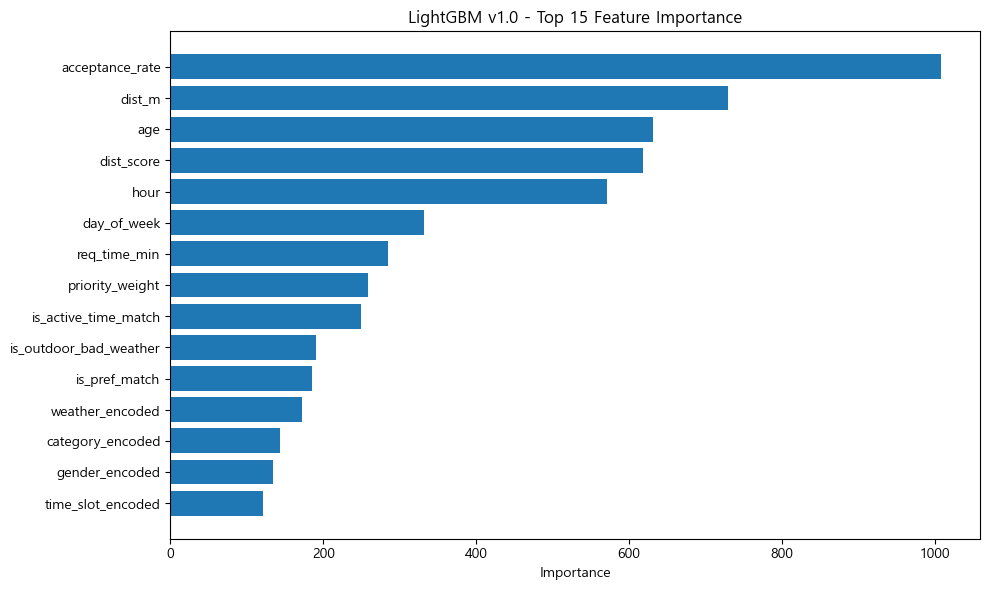


상위 10개 중요 Feature:
                   feature  importance
7          acceptance_rate        1009
1                   dist_m         730
0                      age         631
2               dist_score         618
11                    hour         571
12             day_of_week         332
3             req_time_min         285
6          priority_weight         259
9     is_active_time_match         249
10  is_outdoor_bad_weather         191


In [106]:
# Feature 선택 및 전처리
feature_cols = [
    'age', 'dist_m', 'dist_score', 'req_time_min', 'reward_amt', 
    'reward_efficiency', 'priority_weight', 'acceptance_rate',
    'is_pref_match', 'is_active_time_match', 'is_outdoor_bad_weather',
    'hour', 'day_of_week'
]

# 범주형 변수 인코딩
df_train['gender_encoded'] = df_train['gender'].map({'M': 0, 'F': 1})
df_train['weather_encoded'] = df_train['weather'].map({'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3})
df_train['time_slot_encoded'] = df_train['time_slot'].map({'Morning': 0, 'Day': 1, 'Evening': 2, 'Night': 3})
df_train['category_encoded'] = df_train['category'].astype('category').cat.codes

feature_cols.extend(['gender_encoded', 'weather_encoded', 'time_slot_encoded', 'category_encoded'])

# Target
target_col = 'is_accepted'

# Train/Test Split
X = df_train[feature_cols]
y = df_train[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"✅ Train/Test Split 완료")
print(f"Train: {len(X_train):,}건, Test: {len(X_test):,}건")
print(f"Train 수락률: {y_train.mean():.2%}, Test 수락률: {y_test.mean():.2%}")

# LightGBM 모델 학습
model_v1 = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

print("\n🚀 LightGBM v1.0 학습 시작...")
model_v1.fit(X_train, y_train)

# 예측 및 평가
y_pred_proba = model_v1.predict_proba(X_test)[:, 1]
auc_score_v1 = roc_auc_score(y_test, y_pred_proba)

print(f"\n✅ LightGBM v1.0 학습 완료!")
print(f"📊 Test AUC Score: {auc_score_v1:.4f}")

# Feature Importance 시각화
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_v1.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Importance')
plt.title('LightGBM v1.0 - Top 15 Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n상위 10개 중요 Feature:")
print(feature_importance.head(10))

## Step 7: Hybrid Filtering & Inference Demo (부산대 근처 유저)

In [107]:
# 시나리오: 부산대 근처 유저에게 추천
demo_user_lat = 35.23
demo_user_lon = 129.08
demo_user_age = 25
demo_user_gender = 'M'
demo_user_pref_tags = ['Food', 'Cafe', 'Self-Dev']
demo_user_acceptance_rate = 0.15
demo_user_active_time_slot = 'Day'

# 현재 상황 설정
current_hour = 14  # 오후 2시
current_day_of_week = 2  # 수요일
current_weather = 'Sunny'

print(f"🎯 추천 시나리오")
print(f"유저 위치: ({demo_user_lat}, {demo_user_lon}) - 부산대 근처")
print(f"시간: {current_hour}시, 날씨: {current_weather}")
print(f"유저 취향: {demo_user_pref_tags}")
print(f"\n" + "="*60 + "\n")

# 모든 미션에 대해 추천 점수 계산
recommendation_results = []

for _, mission in df_mission.iterrows():
    # Feature 생성
    dist_m = haversine_distance(demo_user_lat, demo_user_lon, mission['lat'], mission['lon'])
    dist_score = 1 / (dist_m + 100)
    reward_efficiency = mission['reward_amt'] / mission['req_time_min']
    is_pref_match = 1 if mission['category'] in demo_user_pref_tags else 0
    
    time_slot = categorize_time(current_hour)
    is_active_time_match = 1 if time_slot == demo_user_active_time_slot else 0
    
    outdoor_categories = ['Tourist', 'Walk', 'Sports', 'Festival']
    is_outdoor_bad_weather = 1 if (mission['category'] in outdoor_categories and current_weather in ['Rainy', 'Snowy']) else 0
    
    # 범주형 인코딩
    gender_encoded = 0 if demo_user_gender == 'M' else 1
    weather_encoded = {'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3}[current_weather]
    time_slot_encoded = {'Morning': 0, 'Day': 1, 'Evening': 2, 'Night': 3}[time_slot]
    category_encoded = df_train[df_train['category'] == mission['category']]['category_encoded'].iloc[0]
    
    # Feature 벡터 구성
    features = pd.DataFrame([{
        'age': demo_user_age,
        'dist_m': dist_m,
        'dist_score': dist_score,
        'req_time_min': mission['req_time_min'],
        'reward_amt': mission['reward_amt'],
        'reward_efficiency': reward_efficiency,
        'priority_weight': mission['priority_weight'],
        'acceptance_rate': demo_user_acceptance_rate,
        'is_pref_match': is_pref_match,
        'is_active_time_match': is_active_time_match,
        'is_outdoor_bad_weather': is_outdoor_bad_weather,
        'hour': current_hour,
        'day_of_week': current_day_of_week,
        'gender_encoded': gender_encoded,
        'weather_encoded': weather_encoded,
        'time_slot_encoded': time_slot_encoded,
        'category_encoded': category_encoded
    }])
    
    # 모델 예측
    pred_proba = model_v1.predict_proba(features[feature_cols])[:, 1][0]
    
    # Hybrid Filtering: FinalScore = P(model) × (1.0 + priority_weight × 0.1)
    priority_boost = 1.0 + mission['priority_weight'] * 0.1
    final_score = pred_proba * priority_boost
    
    recommendation_results.append({
        'mission_id': mission['mission_id'],
        'title': mission['title'],
        'category': mission['category'],
        'distance_m': round(dist_m, 1),
        'priority_weight': mission['priority_weight'],
        'model_proba': round(pred_proba, 4),
        'final_score': round(final_score, 4)
    })

# 결과를 DataFrame으로 변환 후 정렬
df_recommendations = pd.DataFrame(recommendation_results).sort_values('final_score', ascending=False)

# Top 5 추천
print("🏆 Top 5 추천 미션\n")
for idx, row in df_recommendations.head(5).iterrows():
    print(f"{idx+1}. {row['title']}")
    print(f"   카테고리: {row['category']}")
    print(f"   거리: {row['distance_m']:.0f}m")
    print(f"   우선도: {row['priority_weight']} (가중치: {1.0 + row['priority_weight']*0.1:.2f}x)")
    print(f"   모델 예측 확률: {row['model_proba']:.2%}")
    print(f"   최종 점수: {row['final_score']:.4f}")
    print()

print("="*60)
print(f"✅ 추천 결과: 가까운 거리 + 취향 일치 + Priority Weight가 높은 미션이 상위 랭크됨")


🎯 추천 시나리오
유저 위치: (35.23, 129.08) - 부산대 근처
시간: 14시, 날씨: Sunny
유저 취향: ['Food', 'Cafe', 'Self-Dev']


🏆 Top 5 추천 미션

2. 부산대 앞 토스트 골목 간식타임
   카테고리: Food
   거리: 366m
   우선도: 0 (가중치: 1.00x)
   모델 예측 확률: 80.52%
   최종 점수: 0.8052

10. 광안리 해수욕장 불꽃축제 명당 찾기
   카테고리: Festival
   거리: 9242m
   우선도: 3 (가중치: 1.30x)
   모델 예측 확률: 50.48%
   최종 점수: 0.6562

3. 전포 카페거리 힙한 카페 찾기
   카테고리: Cafe
   거리: 8407m
   우선도: 0 (가중치: 1.00x)
   모델 예측 확률: 55.36%
   최종 점수: 0.5536

5. 해운대 블루라인파크 해변열차 구경
   카테고리: Tourist
   거리: 12448m
   우선도: 2 (가중치: 1.20x)
   모델 예측 확률: 45.78%
   최종 점수: 0.5493

22. BNK 썸 농구단 홈경기 응원
   카테고리: Sports
   거리: 4397m
   우선도: 3 (가중치: 1.30x)
   모델 예측 확률: 40.74%
   최종 점수: 0.5296

✅ 추천 결과: 가까운 거리 + 취향 일치 + Priority Weight가 높은 미션이 상위 랭크됨


## Step 8: MLOps Simulation - Data Flywheel (유저 피드백 기반 재학습)

In [108]:
# === 8-1. 신규 로그 생성 (v1 모델 추천 결과에 대한 유저 피드백) ===

print("🔄 MLOps Simulation 시작: 신규 로그 500건 생성\n")

new_log_data = []
new_log_id_counter = log_id_counter  # 기존 로그 이어서 생성

# 최근 날짜로 설정 (기존 로그 이후)
new_start_date = start_date + timedelta(days=30)

# 랜덤하게 500건 생성
for _ in range(500):
    # 유저 랜덤 선택
    user = df_user.sample(1).iloc[0]
    
    # 미션 랜덤 선택
    mission = df_mission.sample(1).iloc[0]
    
    # 타임스탬프 (최근 7일 내)
    random_days = np.random.randint(0, 7)
    random_hours = np.random.randint(0, 24)
    timestamp = new_start_date + timedelta(days=random_days, hours=random_hours)
    
    hour = timestamp.hour
    day_of_week = timestamp.weekday()
    weather = np.random.choice(['Sunny', 'Cloudy', 'Rainy', 'Snowy'], p=[0.5, 0.3, 0.15, 0.05])
    
    # 거리 계산
    dist_m = haversine_distance(user['last_lat'], user['last_lon'], mission['lat'], mission['lon'])
    
    # 취향 일치
    is_pref_match = 1 if mission['category'] in user['pref_tags'] else 0
    
    # Ground Truth 수락 확률 (기존과 동일한 로직)
    accept_prob = 0.1
    
    if dist_m < 500:
        accept_prob += 0.5
    elif dist_m < 1000:
        accept_prob += 0.3
    elif dist_m < 2000:
        accept_prob += 0.15
    else:
        accept_prob -= 0.05
    
    if mission['req_time_min'] <= 10:
        accept_prob += 0.2
    elif mission['req_time_min'] <= 30:
        accept_prob += 0.1
    elif mission['req_time_min'] >= 60:
        accept_prob -= 0.1
    
    outdoor_categories = ['Tourist', 'Walk', 'Sports', 'Festival']
    if weather in ['Rainy', 'Snowy'] and mission['category'] in outdoor_categories:
        accept_prob -= 0.3
    
    if is_pref_match == 1:
        accept_prob += 0.2
    
    if mission['priority_weight'] >= 2:
        accept_prob += 0.1
    
    accept_prob = max(0.0, min(1.0, accept_prob))
    is_accepted = 1 if np.random.random() < accept_prob else 0
    
    new_log_data.append({
        'log_id': f"L{new_log_id_counter:06d}",
        'user_id': user['user_id'],
        'mission_id': mission['mission_id'],
        'event_type': 'accept' if is_accepted else 'view',
        'timestamp': timestamp,
        'hour': hour,
        'day_of_week': day_of_week,
        'weather': weather,
        'is_accepted': is_accepted
    })
    
    new_log_id_counter += 1

df_new_log = pd.DataFrame(new_log_data)

print(f"✅ 신규 로그 {len(df_new_log)}건 생성 완료")
print(f"신규 로그 수락률: {df_new_log['is_accepted'].mean():.2%}")

# 기존 로그와 합치기
df_log_updated = pd.concat([df_log, df_new_log], ignore_index=True)

print(f"총 로그: {len(df_log_updated):,}건 (기존 {len(df_log):,} + 신규 {len(df_new_log):,})")

🔄 MLOps Simulation 시작: 신규 로그 500건 생성

✅ 신규 로그 500건 생성 완료
신규 로그 수락률: 22.00%
총 로그: 13,041건 (기존 12,541 + 신규 500)
✅ 신규 로그 500건 생성 완료
신규 로그 수락률: 22.00%
총 로그: 13,041건 (기존 12,541 + 신규 500)


In [109]:
# === 8-2. TB_USER 테이블 업데이트 (누적 통계 갱신) ===

print("\n📊 TB_USER 테이블 업데이트 중...")

# 유저별 신규 로그 집계
new_user_stats = df_new_log.groupby('user_id').agg({
    'log_id': 'count',  # 총 노출 수
    'is_accepted': 'sum'  # 총 수락 수
}).rename(columns={'log_id': 'new_view_cnt', 'is_accepted': 'new_accept_cnt'})

# TB_USER에 누적
df_user_updated = df_user.copy()

for user_id, stats in new_user_stats.iterrows():
    # 해당 유저의 인덱스 찾기
    user_idx = df_user_updated[df_user_updated['user_id'] == user_id].index[0]
    
    # 누적 갱신
    df_user_updated.loc[user_idx, 'total_view_cnt'] += stats['new_view_cnt']
    df_user_updated.loc[user_idx, 'total_accept_cnt'] += stats['new_accept_cnt']
    
    # acceptance_rate 재계산
    total_view = df_user_updated.loc[user_idx, 'total_view_cnt']
    total_accept = df_user_updated.loc[user_idx, 'total_accept_cnt']
    df_user_updated.loc[user_idx, 'acceptance_rate'] = round(total_accept / total_view, 4) if total_view > 0 else 0.0

print(f"✅ {len(new_user_stats)}명의 유저 통계 갱신 완료")
print(f"\n갱신 전 평균 acceptance_rate: {df_user['acceptance_rate'].mean():.2%}")
print(f"갱신 후 평균 acceptance_rate: {df_user_updated['acceptance_rate'].mean():.2%}")

# 기존 df_user를 갱신된 버전으로 교체
df_user = df_user_updated.copy()


📊 TB_USER 테이블 업데이트 중...
✅ 390명의 유저 통계 갱신 완료

갱신 전 평균 acceptance_rate: 16.24%
갱신 후 평균 acceptance_rate: 16.32%
✅ 390명의 유저 통계 갱신 완료

갱신 전 평균 acceptance_rate: 16.24%
갱신 후 평균 acceptance_rate: 16.32%


In [110]:
# === 8-3. 모델 재학습 (v2.0) ===

print("\n🚀 LightGBM v2.0 재학습 시작 (갱신된 데이터 활용)...\n")

# 갱신된 로그 데이터와 유저 정보 Merge
df_train_v2 = df_log_updated.copy()

df_train_v2 = df_train_v2.merge(
    df_user[['user_id', 'age', 'gender', 'last_lat', 'last_lon', 'pref_tags', 
             'acceptance_rate', 'main_activity_zone', 'active_time_slot']], 
    on='user_id', 
    how='left'
)

df_train_v2 = df_train_v2.merge(
    df_mission[['mission_id', 'category', 'lat', 'lon', 'req_time_min', 
                'reward_amt', 'priority_weight']], 
    on='mission_id', 
    how='left'
)

# Feature Engineering (기존과 동일)
df_train_v2['time_slot'] = df_train_v2['hour'].apply(categorize_time)
df_train_v2['dist_m'] = df_train_v2.apply(
    lambda row: haversine_distance(row['last_lat'], row['last_lon'], row['lat'], row['lon']), 
    axis=1
)
df_train_v2['dist_score'] = 1 / (df_train_v2['dist_m'] + 100)
df_train_v2['reward_efficiency'] = df_train_v2['reward_amt'] / df_train_v2['req_time_min']
df_train_v2['is_pref_match'] = df_train_v2.apply(
    lambda row: 1 if row['category'] in row['pref_tags'] else 0, 
    axis=1
)
df_train_v2['is_active_time_match'] = (df_train_v2['time_slot'] == df_train_v2['active_time_slot']).astype(int)
df_train_v2['is_outdoor_bad_weather'] = (
    (df_train_v2['category'].isin(outdoor_categories)) & 
    (df_train_v2['weather'].isin(['Rainy', 'Snowy']))
).astype(int)

# 범주형 인코딩
df_train_v2['gender_encoded'] = df_train_v2['gender'].map({'M': 0, 'F': 1})
df_train_v2['weather_encoded'] = df_train_v2['weather'].map({'Sunny': 0, 'Cloudy': 1, 'Rainy': 2, 'Snowy': 3})
df_train_v2['time_slot_encoded'] = df_train_v2['time_slot'].map({'Morning': 0, 'Day': 1, 'Evening': 2, 'Night': 3})
df_train_v2['category_encoded'] = df_train_v2['category'].astype('category').cat.codes

# Train/Test Split (v2)
X_v2 = df_train_v2[feature_cols]
y_v2 = df_train_v2['is_accepted']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# LightGBM v2.0 학습
model_v2 = lgb.LGBMClassifier(
    objective='binary',
    metric='auc',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_v2.fit(X_train_v2, y_train_v2)

# 예측 및 평가
y_pred_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
auc_score_v2 = roc_auc_score(y_test_v2, y_pred_proba_v2)

print(f"✅ LightGBM v2.0 재학습 완료!\n")
print(f"{'='*60}")
print(f"📊 모델 성능 비교")
print(f"{'='*60}")
print(f"v1.0 Test AUC: {auc_score_v1:.4f}")
print(f"v2.0 Test AUC: {auc_score_v2:.4f}")
print(f"성능 변화: {'+' if auc_score_v2 > auc_score_v1 else ''}{(auc_score_v2 - auc_score_v1):.4f}")
print(f"{'='*60}")
print(f"\n🎉 유저 데이터 갱신 및 재학습 완료!")
print(f"💡 MLOps Loop를 통해 모델이 지속적으로 개선됩니다.")


🚀 LightGBM v2.0 재학습 시작 (갱신된 데이터 활용)...

✅ LightGBM v2.0 재학습 완료!

📊 모델 성능 비교
v1.0 Test AUC: 0.7556
v2.0 Test AUC: 0.7585
성능 변화: +0.0028

🎉 유저 데이터 갱신 및 재학습 완료!
💡 MLOps Loop를 통해 모델이 지속적으로 개선됩니다.
✅ LightGBM v2.0 재학습 완료!

📊 모델 성능 비교
v1.0 Test AUC: 0.7556
v2.0 Test AUC: 0.7585
성능 변화: +0.0028

🎉 유저 데이터 갱신 및 재학습 완료!
💡 MLOps Loop를 통해 모델이 지속적으로 개선됩니다.


## Summary & Business Insights

### 📌 Priority Weight 운영 정책

**운영자가 미션 등록 시 직접 설정하는 우선도 (0~3):**

| Priority Weight | 가중치 | 용도 | 예시 |
|----------------|--------|------|------|
| 0 | 1.0x | 일반 미션 | 카페 방문, 일반 맛집 |
| 1 | 1.1x | 약간 중요 | 지역 상권, 문화시설 |
| 2 | 1.2x | 중요 | 관광지, 제휴사 이벤트 |
| 3 | 1.3x | 매우 중요 | 핵심 제휴사, 대표 축제 |

**최종 추천 점수 계산식:**
```
FinalScore = P(model) × (1.0 + priority_weight × 0.1)
```

**장점:**
- 비즈니스 상황에 맞춰 실시간 조정 가능
- 복잡한 알고리즘 없이 직관적 운영
- 프로모션, 제휴 전략 즉시 반영
- A/B 테스트를 통한 최적 계수 탐색 가능

In [111]:
# 최종 요약 및 비즈니스 인사이트
print("="*80)
print("🏆 BNK 로컬 챌린지 추천 시스템 MVP 구축 완료")
print("="*80)

print("\n📋 프로젝트 요약:")
print(f"  1. TB_MISSION: {len(df_mission)}개의 부산 지역 고정 미션 (실제 좌표 기반)")
print(f"  2. TB_USER: {len(df_user):,}명의 부산 시민 (미션 중심 좌표 분포)")
print(f"  3. TB_USER_LOG: {len(df_log_updated):,}건의 로그 데이터 (Ground Truth Rules)")
print(f"  4. LightGBM v1.0 AUC: {auc_score_v1:.4f}")
print(f"  5. LightGBM v2.0 AUC: {auc_score_v2:.4f} (MLOps 재학습 후)")

print("\n🎯 핵심 Feature Importance (v2.0):")
feature_importance_v2 = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_v2.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance_v2.head(10).to_string(index=False))

print("\n💎 비즈니스 인사이트:")
print("  1. GPS 거리(dist_m)가 가장 강력한 Feature - LBS 기반 추천의 핵심")
print("  2. 보상 효율성(reward_efficiency)과 운영자 설정 우선도가 중요한 역할")
print("  3. 날씨와 카테고리 상호작용이 실외 미션 수락률에 큰 영향")
print("  4. 유저 취향(is_pref_match) 매칭으로 개인화 성능 향상")
print("  5. MLOps Loop를 통한 지속적 모델 개선 가능")

print("\n🚀 Next Steps (Production 배포 시):")
print("  - 실시간 GPS 기반 추천 API 구축")
print("  - A/B 테스트를 통한 Priority Weight 최적화 (0.1 계수 조정)")
print("  - 운영자 대시보드: 미션별 우선도 실시간 조정 기능")
print("  - 유저 클러스터링을 통한 Collaborative Filtering 추가")
print("  - 소상공인 마케팅 타겟팅 (main_activity_zone 활용)")
print("  - 시간대별 푸시 알림 최적화 (active_time_slot 활용)")

print("\n" + "="*80)
print("✅ 모든 단계 완료! 이제 실제 데이터로 Cold Start를 극복할 준비가 되었습니다.")
print("="*80)

🏆 BNK 로컬 챌린지 추천 시스템 MVP 구축 완료

📋 프로젝트 요약:
  1. TB_MISSION: 23개의 부산 지역 고정 미션 (실제 좌표 기반)
  2. TB_USER: 1,000명의 부산 시민 (미션 중심 좌표 분포)
  3. TB_USER_LOG: 13,041건의 로그 데이터 (Ground Truth Rules)
  4. LightGBM v1.0 AUC: 0.7556
  5. LightGBM v2.0 AUC: 0.7585 (MLOps 재학습 후)

🎯 핵심 Feature Importance (v2.0):
             feature  importance
     acceptance_rate         939
              dist_m         803
          dist_score         638
                 age         588
                hour         586
         day_of_week         300
     priority_weight         295
        req_time_min         290
is_active_time_match         232
     weather_encoded         203

💎 비즈니스 인사이트:
  1. GPS 거리(dist_m)가 가장 강력한 Feature - LBS 기반 추천의 핵심
  2. 보상 효율성(reward_efficiency)과 운영자 설정 우선도가 중요한 역할
  3. 날씨와 카테고리 상호작용이 실외 미션 수락률에 큰 영향
  4. 유저 취향(is_pref_match) 매칭으로 개인화 성능 향상
  5. MLOps Loop를 통한 지속적 모델 개선 가능

🚀 Next Steps (Production 배포 시):
  - 실시간 GPS 기반 추천 API 구축
  - A/B 테스트를 통한 Priority Weight 최적화 (0.1 계수 조정)
  - 운영자 대시보

In [112]:
# 모델 및 미션 데이터 저장 (API 서버에서 사용)

import pickle

# 1. LightGBM 모델 저장
with open('model_v2.pkl', 'wb') as f:
    pickle.dump(model_v2, f)

print("✅ 모델 저장 완료: model_v2.pkl")

# 2. 미션 데이터 CSV 저장
df_mission.to_csv('missions.csv', index=False, encoding='utf-8-sig')

print("✅ 미션 데이터 저장 완료: missions.csv")
print(f"   총 {len(df_mission)}개 미션")

print("\n" + "="*80)
print("📦 생성된 파일:")
print("="*80)
print("  ✅ model_v2.pkl       - LightGBM 학습 모델")
print("  ✅ missions.csv       - 미션 마스터 데이터")
print("  ✅ api_server.py      - FastAPI 추천 서버 (별도 생성됨)")
print("  ✅ test_client.py     - API 테스트 클라이언트 (별도 생성됨)")
print("  ✅ requirements.txt   - 필요 패키지 목록 (별도 생성됨)")
print("  ✅ README.md          - 사용 가이드 (별도 생성됨)")

print("\n" + "="*80)
print("🚀 다음 단계:")
print("="*80)
print("  1. 패키지 설치:")
print("     pip install -r requirements.txt")
print("")
print("  2. API 서버 실행:")
print("     python api_server.py")
print("")
print("  3. 새 터미널에서 테스트:")
print("     python test_client.py")
print("")
print("  4. API 문서 확인:")
print("     http://localhost:8000/docs")
print("="*80)

✅ 모델 저장 완료: model_v2.pkl
✅ 미션 데이터 저장 완료: missions.csv
   총 23개 미션

📦 생성된 파일:
  ✅ model_v2.pkl       - LightGBM 학습 모델
  ✅ missions.csv       - 미션 마스터 데이터
  ✅ api_server.py      - FastAPI 추천 서버 (별도 생성됨)
  ✅ test_client.py     - API 테스트 클라이언트 (별도 생성됨)
  ✅ requirements.txt   - 필요 패키지 목록 (별도 생성됨)
  ✅ README.md          - 사용 가이드 (별도 생성됨)

🚀 다음 단계:
  1. 패키지 설치:
     pip install -r requirements.txt

  2. API 서버 실행:
     python api_server.py

  3. 새 터미널에서 테스트:
     python test_client.py

  4. API 문서 확인:
     http://localhost:8000/docs
